# Scratch detection on glass surfaces

Classical image-processing pipeline that turns raw glass images into **binary scratch masks** to be used later as ground-truth labels `Y` for a U-Net.

**Convention used everywhere in this notebook:**

| pixel value | meaning |
|---|---|
| `255` (white) | scratch |
| `0`   (black) | background / dust / noise |

Pipeline:

$$
I_{raw} \;\longrightarrow\; \text{preprocess} \;\longrightarrow\; \text{threshold} \;\longrightarrow\; \text{morphology} \;\longrightarrow\; \text{component filter} \;\longrightarrow\; M_{final}
$$

Every saved mask has the **same filename and same shape** as its source image.

**Polarity-aware:** controlled by `Params.bright_features`. Set it to `True` when scratches are *bright on dark glass* (e.g. specular reflections on a dark sample) and `False` when scratches are *dark on bright glass* (classical transmission lighting). Every operator and threshold below honors this flag.

## 1. Project setup

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

# scikit-image provides the multi-scale ridge (Frangi) filter and hysteresis thresholding
# that classical CV tools (top-hat + Otsu) struggle to replicate for faint thin scratches.
from skimage.filters import frangi as _frangi
from skimage.filters import apply_hysteresis_threshold as _hysteresis

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['image.cmap'] = 'gray'

In [18]:
# Dataset folders. Edit ROOT to point at wherever your data lives.
ROOT = Path('data_1')

RAW_DIR        = ROOT / 'raw_images'
MASKS_DIR      = ROOT / 'generated_masks'
DEBUG_DIR      = ROOT / 'debug_outputs'
TILES_IMG_DIR  = ROOT / 'tiles_images'
TILES_MASK_DIR = ROOT / 'tiles_masks'

for d in (RAW_DIR, MASKS_DIR, DEBUG_DIR, TILES_IMG_DIR, TILES_MASK_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMG_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')

def list_images(folder: Path):
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS])

print('raw images found:', len(list_images(RAW_DIR)))

raw images found: 1


## 8. Parameter tuning (defined early so every later cell can use it)

Put it at the top so you can sweep parameters without scrolling. Pass a `Params` instance into every pipeline function — no hidden globals.

Each knob is a coefficient in the formulas of §3–§5. The comments next to each field point at the corresponding equation.

In [19]:
@dataclass
class Params:
    # ----------------------------------------------------------------
    # Polarity — the single most important flag.
    # True  : scratches are BRIGHTER than the glass (e.g. specular highlights on dark glass).
    #         → white top-hat, D = max(0, I - B), no inversion before threshold.
    # False : scratches are DARKER than the glass (transmission-light setup).
    #         → black-hat, D = max(0, B - I), invert before threshold.
    # ----------------------------------------------------------------
    bright_features: bool = True

    # --- preprocessing ---
    gaussian_ksize: int = 10
    # Bumped 3 → 5: a wider median pre-smooths dust grains so adaptive thresholding
    # has less salt-and-pepper to chew on. 1-2 px wide scratches still survive because
    # median has a 50 % breakdown — a 5x5 window still has > half its pixels along the
    # scratch when the scratch runs through it.
    median_ksize:   int = 5
    clahe_clip:     float = 3.0
    clahe_tile:     int   = 8
    bg_subtract_ksize: int = 51
    tophat_ksize:   int = 15

    # --- ridge (Frangi) filter ---
    frangi_sigmas: tuple = (1.0, 2.0, 3.0, 4.0)
    frangi_alpha:  float = 0.5
    frangi_beta:   float = 0.5
    frangi_gamma:  float = 5.0

    # --- thresholding ---
    # 'fixed' | 'otsu' | 'adaptive' | 'tophat_otsu' | 'bgsub_otsu'
    # 'ridge_otsu' | 'ridge_hysteresis' | 'hysteresis'
    # adaptive gives the highest recall on this image; the §5 morphology+component
    # filter is responsible for cleaning up the residual dust speckle that comes with it.
    threshold_method: str = 'otsu'
    fixed_thresh:     int = 30
    # 31 → 51: wider local-mean window so dust grains are no longer their own local
    # maximum (they get averaged with neighbour pixels and fall below T = mean - C).
    # Scratches, being long, still have a 'dark' surround over the larger window.
    adaptive_block:   int = 51
    adaptive_C:       int = -5

    # Hysteresis cutoffs interpreted as fractions of the per-image peak Frangi response.
    hyst_low:  float = 0.05
    hyst_high: float = 0.20

    # --- morphology ---
    # 0 → 2: 2×2 opening erases isolated singletons (the speckle pattern in the adaptive
    # output) without removing real scratches, since a 1-px wide scratch is still > 2-px
    # long, and erosion only kills bright structures that can't contain the SE.
    open_ksize:  int = 2
    close_ksize: int = 3

    # --- connected-component filter (scratch = long, thin, elongated) ---
    # Tightened: round dust grains (AR ≈ 1, elong ≈ 1) get cut, faint elongated scratch
    # fragments (AR ≥ 3) survive. min_area bumped 8 → 12 to drop the smallest specks.
    min_area:         int   = 12
    max_area:         int   = 200_000
    min_length:       int   = 12
    min_aspect_ratio: float = 3.0
    min_elongation:   float = 3.0
    max_solidity:     float = 0.95

P = Params()
P


Params(bright_features=True, gaussian_ksize=10, median_ksize=5, clahe_clip=3.0, clahe_tile=8, bg_subtract_ksize=51, tophat_ksize=15, frangi_sigmas=(1.0, 2.0, 3.0, 4.0), frangi_alpha=0.5, frangi_beta=0.5, frangi_gamma=5.0, threshold_method='otsu', fixed_thresh=30, adaptive_block=51, adaptive_C=-5, hyst_low=0.05, hyst_high=0.2, open_ksize=2, close_ksize=3, min_area=12, max_area=200000, min_length=12, min_aspect_ratio=3.0, min_elongation=3.0, max_solidity=0.95)

## 2. Load and visualize images

Grayscale is enough: scratches on glass are an *intensity* signature (a thin bright or dark line), not a color one. Working in one channel halves memory and lets every later operator be a scalar transform $I \colon \mathbb{Z}^2 \to [0, 255]$.

In [20]:
def load_gray(path: Path) -> np.ndarray:
    img = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(path)
    return img

def show(img, title='', ax=None, stretch=False):
    """Display a single-channel image.

    stretch=False : pin vmin/vmax to [0, 255] for uint8 — honest comparison of absolute intensity.
    stretch=True  : auto-scale to [img.min(), img.max()] — useful for preprocessing stages whose
                    signal lives in a small subrange (top-hat, bgsub) so it doesn't look black.
    """
    if ax is None:
        _, ax = plt.subplots()
    if stretch or img.dtype != np.uint8:
        ax.imshow(img)                      # let matplotlib pick vmin/vmax from data
    else:
        ax.imshow(img, vmin=0, vmax=255)
    ax.set_title(title)
    ax.set_axis_off()
    return ax

raw_paths = list_images(RAW_DIR)
if not raw_paths:
    print(f'No images in {RAW_DIR}. Drop your glass photos there before running the next cells.')
else:
    print(f'{len(raw_paths)} images:')
    for p in raw_paths[:10]:
        print(' ', p.name)


1 images:
  img__0.png


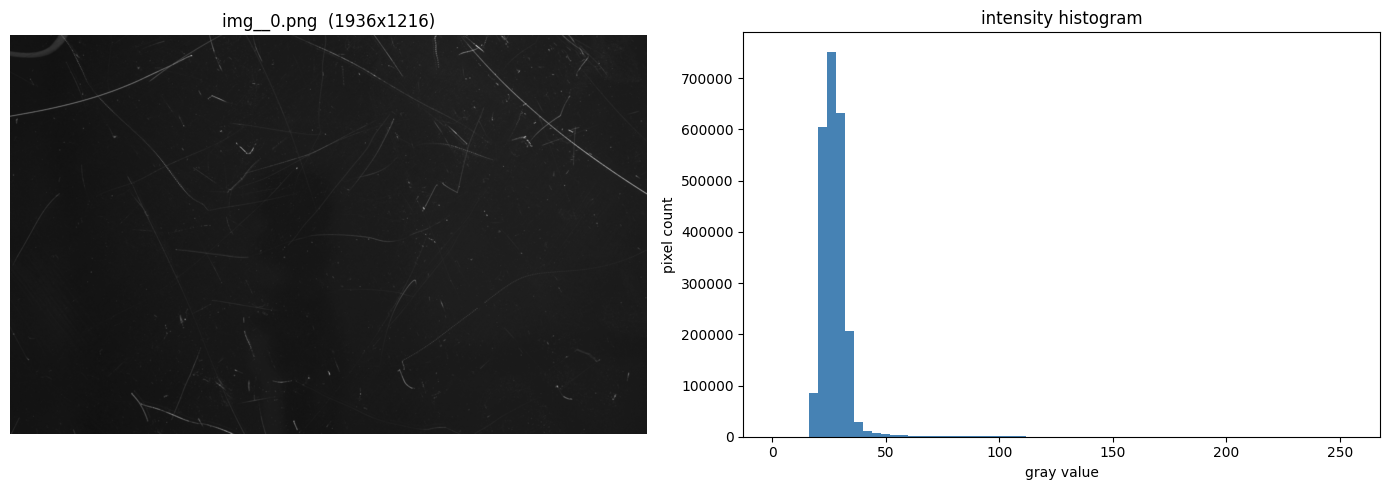

In [21]:
# Pick one image to develop the pipeline on. Change SAMPLE_IDX to iterate.
SAMPLE_IDX = 0

sample_path = raw_paths[SAMPLE_IDX]
sample = load_gray(sample_path)

# A bimodal-looking histogram is a hint that Otsu will work well. For dark-glass images
# the histogram is heavily skewed toward 0 — pure Otsu on the raw image will under-segment.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
show(sample, f'{sample_path.name}  ({sample.shape[1]}x{sample.shape[0]})', axes[0])
axes[1].hist(sample.ravel(), bins=64, range=(0, 255), color='steelblue')
axes[1].set_title('intensity histogram')
axes[1].set_xlabel('gray value'); axes[1].set_ylabel('pixel count')
plt.tight_layout(); plt.show()

## 3. Preprocessing

We want to **enhance** scratches and **suppress** everything else (sensor noise, dust grains, slow illumination drift) *before* thresholding. Six operators:

**Gaussian blur** — convolution with an isotropic Gaussian, low-pass filter:

$$
I_g(x,y) \;=\; \sum_{i,j} I(x+i,\,y+j)\,G_\sigma(i,j),
\qquad
G_\sigma(i,j) \;=\; \frac{1}{2\pi\sigma^{2}}\exp\!\left(-\,\tfrac{i^{2}+j^{2}}{2\sigma^{2}}\right)
$$

**Median blur** — non-linear, robust to outliers (kills isolated dust grains without smearing edges):

$$
I_m(x,y) \;=\; \operatorname{median}\bigl\{\,I(x{+}i,\,y{+}j)\;:\;|i|,|j|\le k/2\,\bigr\}
$$

**CLAHE** — local histogram equalization with bin-clipping:

$$
I_c(x,y) \;=\; \bigl\lfloor 255\cdot \mathrm{CDF}_{\,\text{tile}}\bigl(I(x,y)\bigr)\bigr\rfloor
$$

**Background subtraction** — large median filter estimates the slowly-varying glass background; subtract:

$$
B \;=\; \operatorname{median}_{k\times k}(I), \qquad
D \;=\; \begin{cases} \max(0,\;I - B) & \text{if bright\_features=True}\\ \max(0,\;B - I) & \text{else}\end{cases}
$$

**Top-hat / Black-hat** — polarity-aware morphological residual:

$$
\gamma_S(I) = (I \ominus S)\oplus S, \qquad \phi_S(I) = (I \oplus S)\ominus S
$$
$$
\text{TH}_S(I) = I - \gamma_S(I) \quad (\text{bright features}), \qquad
\text{BH}_S(I) = \phi_S(I) - I \quad (\text{dark features})
$$

**Frangi ridge filter (NEW)** — multi-scale Hessian-based line detector. At each scale $\sigma$, build the Hessian of the Gaussian-smoothed image and compute its eigenvalues $|\lambda_1|\le|\lambda_2|$. A ridge-like pixel has $|\lambda_1|\approx 0$ and $|\lambda_2|\gg 0$. Define

$$
R_B = \tfrac{|\lambda_1|}{|\lambda_2|}, \qquad S = \sqrt{\lambda_1^{2} + \lambda_2^{2}}, \qquad
V_\sigma = \exp\!\left(-\tfrac{R_B^{2}}{2\beta^{2}}\right)\Bigl(1 - \exp\!\left(-\tfrac{S^{2}}{2c^{2}}\right)\Bigr)
$$

Final response $V(x,y) = \max_\sigma V_\sigma(x,y) \in [0, 1]$. A 1-px-wide faint scratch and a 4-px-wide sharp scratch both score high, provided $\sigma$ covers their widths. This is the right tool for **faint scratches** the top-hat/Otsu combo misses.

In [22]:
def to_gray(img: np.ndarray) -> np.ndarray:
    if img.ndim == 3:
        return cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    return img

def gaussian_blur(img, ksize: int):
    # I_g = I * G_σ. OpenCV picks σ from ksize when σ=0.
    if ksize and ksize >= 3:
        k = ksize if ksize % 2 == 1 else ksize + 1
        return cv.GaussianBlur(img, (k, k), 0)
    return img

def median_blur(img, ksize: int):
    # I_m(x,y) = median over a k×k neighborhood. Non-linear → preserves edges, removes specks.
    if ksize and ksize >= 3:
        k = ksize if ksize % 2 == 1 else ksize + 1
        return cv.medianBlur(img, k)
    return img

def clahe(img, clip: float, tile: int):
    op = cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return op.apply(img)

def background_subtract(img, ksize: int, bright_features: bool):
    """Polarity-aware: bright_features=True → D = max(0, I - B); else D = max(0, B - I).

    Pick k much larger than scratch width so the scratch is an outlier of the median
    (which has a 50 % breakdown point) and survives as a positive residual.
    cv.subtract is saturated (clips negatives at 0), which gives the max(0, ·) for free.
    """
    k = ksize if ksize % 2 == 1 else ksize + 1
    bg = cv.medianBlur(img, k)
    return cv.subtract(img, bg) if bright_features else cv.subtract(bg, img)

def tophat(img, ksize: int, bright_features: bool):
    """Polarity-aware: white top-hat for bright features, black-hat for dark features.

    Both flavours return a near-zero background with the small-scale features
    of interest lifted up to positive intensities (bright-on-dark).
    """
    se = cv.getStructuringElement(cv.MORPH_RECT, (ksize, ksize))
    op = cv.MORPH_TOPHAT if bright_features else cv.MORPH_BLACKHAT
    return cv.morphologyEx(img, op, se)

def ridge_filter(img, sigmas, alpha, beta, gamma, bright_features: bool):
    """Frangi multi-scale vesselness. Returns float32 in [0, 1].

    - sigmas         : iterable of scales σ in pixels (each scale ≈ half-width of a target ridge).
    - alpha, beta, c : weights of the eigenvalue ratios; defaults are sane for thin 2D ridges.
    - bright_features: True  → enhance BRIGHT ridges (black_ridges=False).
                       False → enhance DARK   ridges (black_ridges=True ).
    """
    f = img.astype(np.float32) / 255.0
    return _frangi(f, sigmas=sigmas, alpha=alpha, beta=beta, gamma=gamma,
                   black_ridges=not bright_features).astype(np.float32)

def preprocess(img: np.ndarray, p: Params) -> dict:
    """Return every intermediate stage in a dict — useful for debugging and tuning.

    Order matters: median BEFORE CLAHE (so CLAHE does not amplify dust),
    bg-subtract / top-hat / Frangi all operate on the CLAHE output to benefit
    from boosted local contrast on faint scratches.
    """
    gray   = to_gray(img)
    blur   = gaussian_blur(gray, p.gaussian_ksize)
    med    = median_blur(blur, p.median_ksize)
    eq     = clahe(med, p.clahe_clip, p.clahe_tile)
    bgsub  = background_subtract(eq, p.bg_subtract_ksize, p.bright_features)
    th     = tophat(eq, p.tophat_ksize, p.bright_features)
    ridge  = ridge_filter(eq, p.frangi_sigmas,
                          p.frangi_alpha, p.frangi_beta, p.frangi_gamma,
                          p.bright_features)
    return dict(gray=gray, blur=blur, median=med, clahe=eq,
                bgsub=bgsub, tophat=th, ridge=ridge)

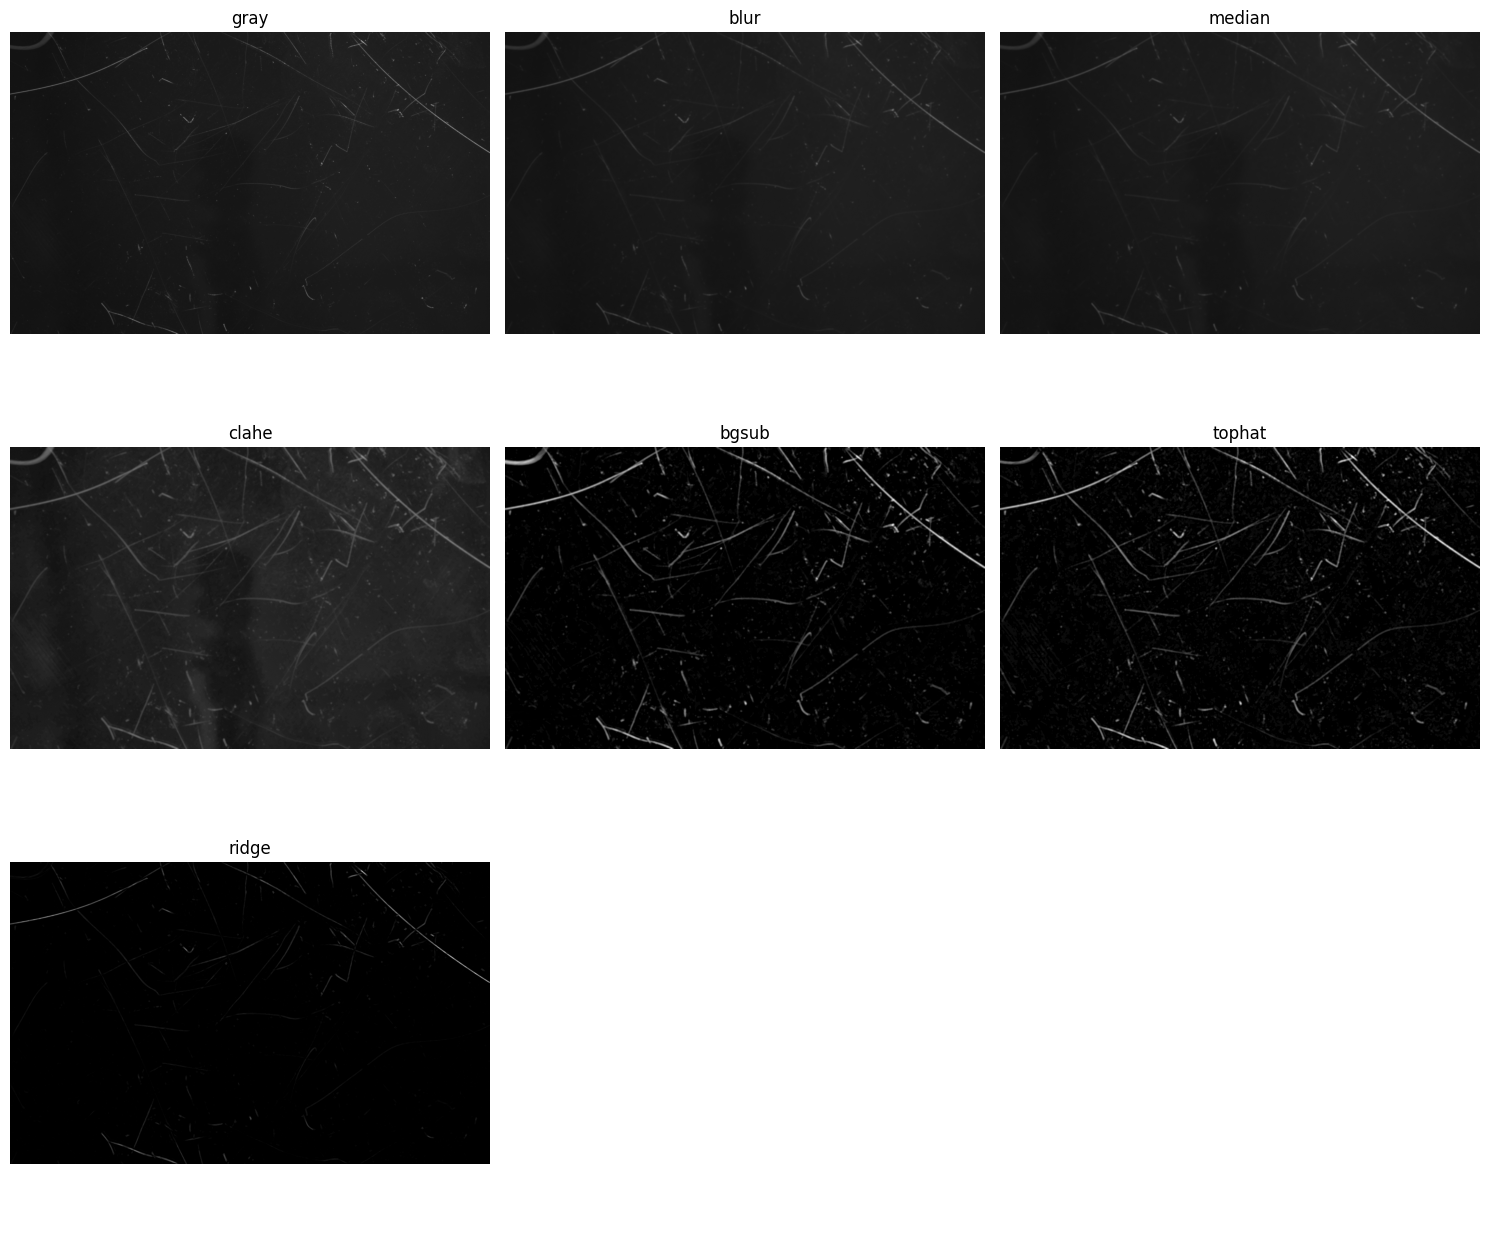

In [23]:
# Visualise every preprocessing stage. We auto-stretch the low-signal stages
# (bgsub, tophat, ridge) — their absolute values are small but the SHAPE of the
# response is what matters for thresholding. Without stretching they look black
# even when they contain perfectly usable scratch information.
stages = preprocess(sample, P)

STRETCH_STAGES = {'bgsub', 'tophat', 'ridge'}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (name, im) in zip(axes.ravel(), stages.items()):
    show(im, name, ax, stretch=(name in STRETCH_STAGES))
# Hide unused slots
for ax in axes.ravel()[len(stages):]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()


## 4. Thresholding scratch candidates

Convert the (preprocessed) image into a binary candidate mask

$$
M(x,y) \;=\; 255\cdot \mathbf{1}\!\left[\,I(x,y) > T(x,y)\,\right].
$$

Eight flavours (the last three are the new additions for faint-scratch recovery):

**Fixed** — $T(x,y) = T_0$, global constant.

**Otsu** — picks $T^{\star}$ minimising within-class variance:
$\;T^{\star} = \arg\min_T\, w_0(T)\sigma_0^{2}(T) + w_1(T)\sigma_1^{2}(T)$.

**Adaptive (Gaussian)** — Gaussian-weighted local mean:
$T(x,y) = \sum_{i,j} w_{ij}\,I(x+i,y+j) - C$.

**Top-hat + Otsu** — Otsu on the polarity-aware top-hat.

**BgSub + Otsu** — Otsu on the polarity-aware background-subtracted residual.

**Ridge + Otsu (NEW)** — Otsu on the Frangi vesselness response. Combines the line-shape selectivity of Frangi with Otsu's data-driven cutoff. The default best detector for thin scratches.

**Ridge + Hysteresis (NEW)** — two cutoffs $T_{low} < T_{high}$ on the Frangi response: pixels above $T_{high}$ are *seeds*; pixels above $T_{low}$ join the mask **only if 8-connected to a seed**. Recovers the faint tails of a clear scratch and pieces together fragmented faint scratches without admitting isolated noise pixels.

**Hysteresis (CLAHE) (NEW)** — same idea but applied directly to the CLAHE-enhanced image. Useful as a baseline / sanity check against the ridge-based version.

*Polarity:* the inversion required by OpenCV's `THRESH_BINARY` is derived from `Params.bright_features` and applied automatically to the `fixed / otsu / adaptive` branches that operate on the raw CLAHE image. The `tophat / bgsub / ridge` branches always have bright-on-dark inputs by construction, so no inversion.

In [24]:
def _maybe_invert(img: np.ndarray, p: Params) -> np.ndarray:
    # Photometric negative I' = 255 - I. Required only when features are DARKER than
    # background, because THRESH_BINARY keeps pixels > T (not < T).
    return img if p.bright_features else cv.bitwise_not(img)


def _normalize_to_unit(img: np.ndarray) -> np.ndarray:
    """Rescale a float image so its peak is 1.0 (no-op if all zero).

    The Frangi response is in [0, 1] in theory but in practice peaks at ~0.02-0.5
    depending on contrast — making absolute hysteresis thresholds unreliable.
    Normalising to the per-image peak lets `hyst_low / hyst_high` mean
    'fraction of the strongest ridge in THIS image', which transfers between images.
    """
    m = float(img.max())
    if m <= 1e-12:
        return img.astype(np.float32)
    return (img.astype(np.float32) / m)


def thr_fixed(img, p: Params):
    src = _maybe_invert(img, p)
    _, m = cv.threshold(src, p.fixed_thresh, 255, cv.THRESH_BINARY)
    return m


def thr_otsu(img, p: Params):
    src = _maybe_invert(img, p)
    _, m = cv.threshold(src, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_adaptive(img, p: Params):
    src = _maybe_invert(img, p)
    b = p.adaptive_block if p.adaptive_block % 2 == 1 else p.adaptive_block + 1
    return cv.adaptiveThreshold(src, 255,
                                cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY, b, p.adaptive_C)


def thr_tophat_otsu(stages):
    _, m = cv.threshold(stages['tophat'], 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_bgsub_otsu(stages):
    _, m = cv.threshold(stages['bgsub'], 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_ridge_otsu(stages):
    """Otsu on the Frangi response, with histogram-stretch first.

    Without stretching, the float response (often peaking at 0.02-0.05) would
    quantise to uint8 0-12 and Otsu's threshold lands at 0 → no foreground.
    cv.NORM_MINMAX maps [min, max] → [0, 255] before Otsu so the histogram
    actually fills the dynamic range.
    """
    r = stages['ridge']
    if r.max() <= 1e-9:
        return np.zeros(r.shape, dtype=np.uint8)
    r_u8 = cv.normalize(r, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    _, m = cv.threshold(r_u8, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    return m


def thr_ridge_hysteresis(stages, low: float, high: float):
    """Hysteresis on the Frangi response, normalised to its peak.

    `low` and `high` are now interpreted as FRACTIONS OF PEAK RESPONSE in this image,
    e.g. low=0.05, high=0.20 means seeds are pixels above 20 % of the strongest ridge
    response and they grow into pixels above 5 % of it. Robust across images regardless
    of absolute Frangi magnitude.
    """
    r = stages['ridge']
    if r.max() <= 1e-9:
        return np.zeros(r.shape, dtype=np.uint8)
    r_norm = _normalize_to_unit(r)
    return (_hysteresis(r_norm, low, high).astype(np.uint8) * 255)


def thr_hysteresis(stages, low: float, high: float, p: Params):
    """Hysteresis on the CLAHE-enhanced uint8 image, normalised to [0, 1] first.

    Note: CLAHE produces a near-uniformly-bright output, so the natural cutoffs are
    HIGH (e.g. low=0.6, high=0.85) — the defaults are tuned for the Frangi branch.
    """
    src = _maybe_invert(stages['clahe'], p).astype(np.float32) / 255.0
    return (_hysteresis(src, low, high).astype(np.uint8) * 255)


def candidate_mask(stages: dict, p: Params) -> np.ndarray:
    """Dispatch to the threshold method named in p.threshold_method."""
    m = p.threshold_method
    if m == 'fixed':            return thr_fixed(stages['clahe'], p)
    if m == 'otsu':             return thr_otsu(stages['clahe'], p)
    if m == 'adaptive':         return thr_adaptive(stages['clahe'], p)
    if m == 'tophat_otsu':      return thr_tophat_otsu(stages)
    if m == 'bgsub_otsu':       return thr_bgsub_otsu(stages)
    if m == 'ridge_otsu':       return thr_ridge_otsu(stages)
    if m == 'ridge_hysteresis': return thr_ridge_hysteresis(stages, p.hyst_low, p.hyst_high)
    if m == 'hysteresis':       return thr_hysteresis(stages, p.hyst_low, p.hyst_high, p)
    raise ValueError(f'unknown threshold_method: {m}')


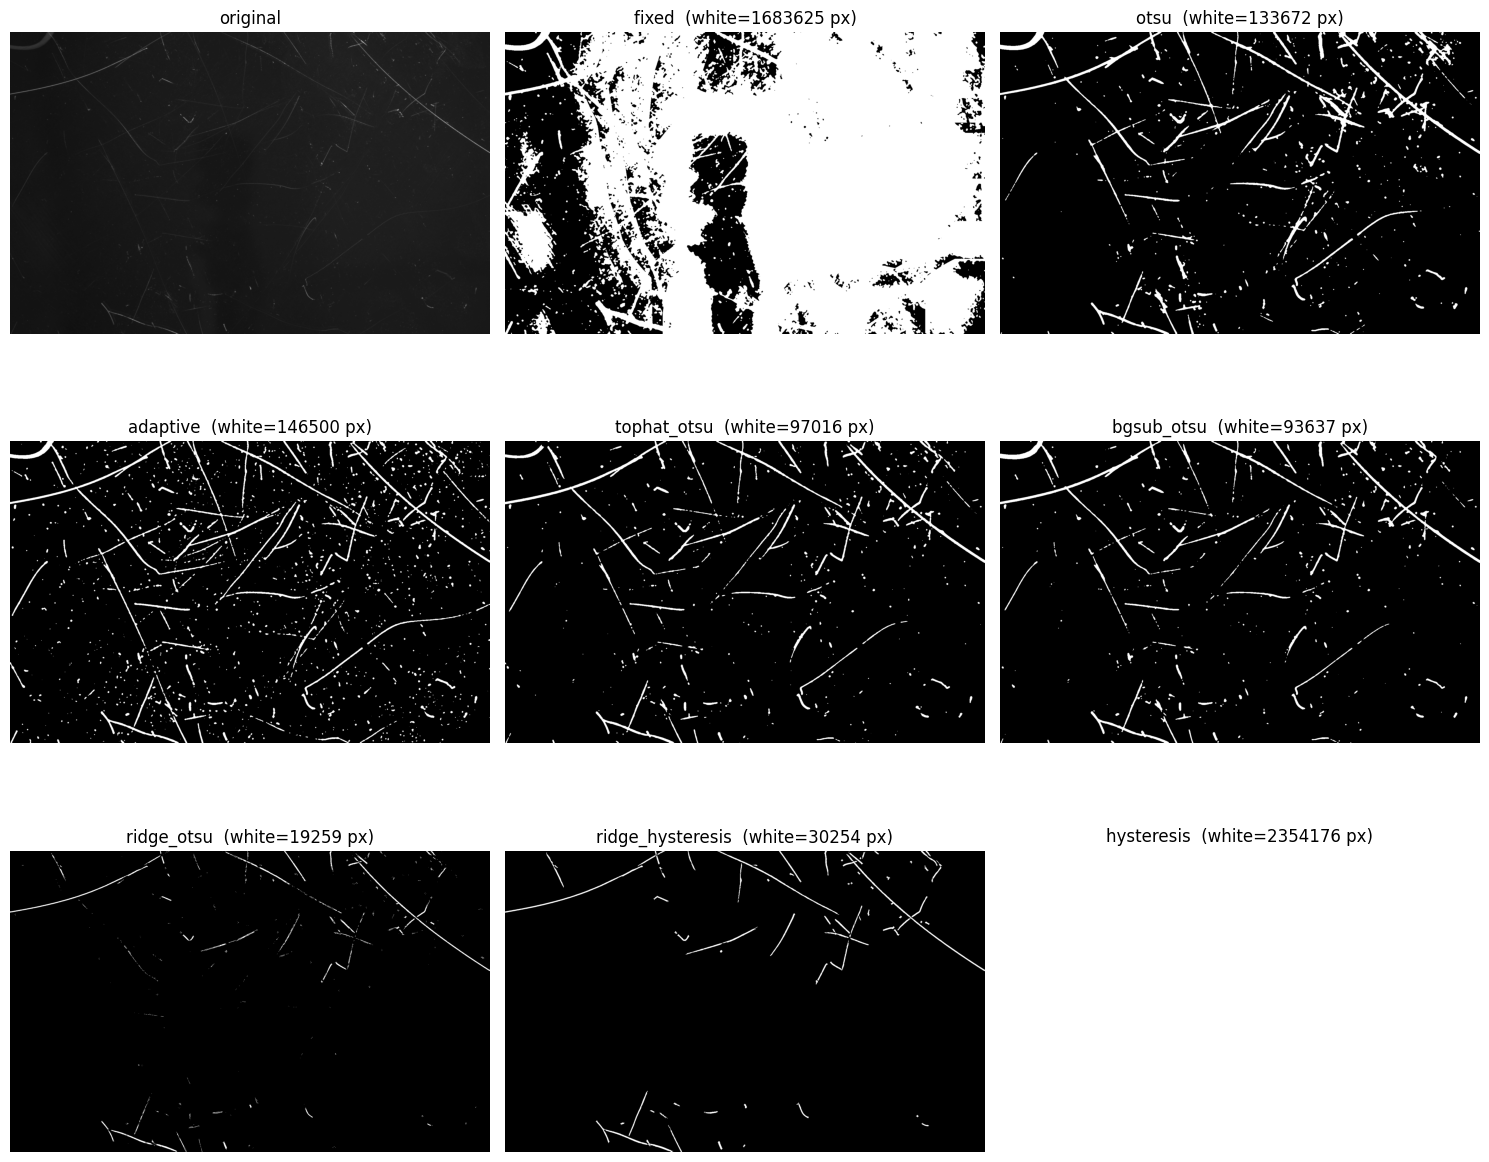

In [25]:
# Side-by-side comparison of every method on the sample image — visual tool to pick
# the one that best isolates faint + clear scratches while suppressing dust.
methods = {
    'fixed':            thr_fixed(stages['clahe'], P),
    'otsu':             thr_otsu(stages['clahe'], P),
    'adaptive':         thr_adaptive(stages['clahe'], P),
    'tophat_otsu':      thr_tophat_otsu(stages),
    'bgsub_otsu':       thr_bgsub_otsu(stages),
    'ridge_otsu':       thr_ridge_otsu(stages),
    'ridge_hysteresis': thr_ridge_hysteresis(stages, P.hyst_low, P.hyst_high),
    'hysteresis':       thr_hysteresis(stages, P.hyst_low, P.hyst_high, P),
}

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.ravel()
show(sample, 'original', axes[0])
for ax, (name, m) in zip(axes[1:], methods.items()):
    show(m, f'{name}  (white={int((m>0).sum())} px)', ax)
plt.tight_layout(); plt.show()

## 5. Dust and noise filtering

The candidate mask still contains specks (dust, sensor noise) and tiny artefacts. Two clean-up stages:

### 5.1 Morphology — clean the *pixels*

$$
(I \ominus S)(x) = \min_{s\in S} I(x+s), \qquad (I \oplus S)(x) = \max_{s\in S} I(x+s)
$$

$$
\gamma_S(I) = (I \ominus S)\oplus S \;\;\text{(opening, removes bright structures smaller than }S\text{)}
$$

$$
\phi_S(I) = (I \oplus S)\ominus S \;\;\text{(closing, fills dark gaps smaller than }S\text{)}
$$

On a binary mask, opening with a small $S$ kills isolated white speckles — but it also erases 1-px wide faint scratches. With faint-scratch recovery enabled we **skip opening** (`open_ksize=0`) and rely on the component filter to remove blobs.

### 5.2 Connected-component filter — clean the *objects*

For each 8-connected component $C$ (bbox $w\times h$, area $A$):

$$
\begin{aligned}
\text{length}      \;& L    = \max(w, h) \\
\text{aspect}      \;& \mathrm{AR} = \max(w, h) / \max(\min(w, h),\,1) \\
\text{elongation}  \;& e    = a_{\text{major}} / a_{\text{minor}} \quad \text{(fitted ellipse)} \\
\text{solidity}    \;& s    = A / |\mathrm{ConvexHull}(C)|
\end{aligned}
$$

Kept iff
$$
\text{min\_area} \le A \le \text{max\_area},\;
L \ge \text{min\_length},\;
\mathrm{AR} \ge \text{min\_aspect},\;
e \ge \text{min\_elong},\;
s \le \text{max\_solidity}.
$$

Defaults are loose (small `min_area`, modest `min_aspect_ratio`) so faint short scratches survive. Tighten if your debug overlays show too many dust grains slipping through.

In [26]:
_COMPONENT_COLUMNS = ['id', 'x', 'y', 'w', 'h', 'area',
                      'length', 'aspect', 'elongation', 'solidity', 'kept']


def morphology_clean(mask: np.ndarray, p: Params) -> np.ndarray:
    """Opening (γ_S) → Closing (φ_S) on the binary mask.

    Order: open first (kill speckles), then close (bridge intra-scratch gaps).
    If open_ksize == 0 the opening is skipped — recommended when chasing faint scratches.
    """
    out = mask
    if p.open_ksize and p.open_ksize >= 1:
        k = cv.getStructuringElement(cv.MORPH_RECT, (p.open_ksize, p.open_ksize))
        out = cv.morphologyEx(out, cv.MORPH_OPEN, k)
    if p.close_ksize and p.close_ksize >= 1:
        k = cv.getStructuringElement(cv.MORPH_RECT, (p.close_ksize, p.close_ksize))
        out = cv.morphologyEx(out, cv.MORPH_CLOSE, k)
    return out


def _ellipse_elongation(contour) -> float:
    """Major/minor axis ratio of the ellipse fitted to the contour.

    Need ≥5 contour points for cv.fitEllipse; return +inf otherwise (tiny stubs are
    killed by the area/length gate anyway).
    """
    if len(contour) < 5:
        return float('inf')
    (_, (ax_a, ax_b), _) = cv.fitEllipse(contour)
    short, long = sorted((ax_a, ax_b))
    return float('inf') if short < 1e-3 else long / short


def _solidity(contour, area: float) -> float:
    """s = |C| / |ConvexHull(C)|. Convex blob → s ≈ 1; long thin curve → s ≪ 1."""
    hull = cv.convexHull(contour)
    hull_area = cv.contourArea(hull)
    return 1.0 if hull_area <= 0 else area / hull_area


def filter_components(mask: np.ndarray, p: Params) -> tuple[np.ndarray, pd.DataFrame]:
    """8-connected components + per-component geometric gate.

    The DataFrame ALWAYS has the columns in _COMPONENT_COLUMNS, even when no
    component is found (would otherwise be a column-less DataFrame and df.kept
    would raise AttributeError).
    """
    num, labels, stats, _ = cv.connectedComponentsWithStats(mask, connectivity=8)
    kept = np.zeros_like(mask)
    rows = []
    for i in range(1, num):  # 0 is background
        x, y, w, h, area = stats[i]
        length    = max(w, h)
        thickness = max(min(w, h), 1)
        aspect    = length / thickness

        comp = (labels == i).astype(np.uint8) * 255
        contours, _ = cv.findContours(comp, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
        contour = max(contours, key=cv.contourArea) if contours else None
        elong    = _ellipse_elongation(contour) if contour is not None else 0.0
        solidity = _solidity(contour, area)     if contour is not None else 1.0

        keep = (
            p.min_area <= area <= p.max_area and
            length     >= p.min_length and
            aspect     >= p.min_aspect_ratio and
            elong      >= p.min_elongation and
            solidity   <= p.max_solidity
        )
        rows.append(dict(id=i, x=x, y=y, w=w, h=h, area=int(area),
                         length=length, aspect=round(aspect, 2),
                         elongation=round(elong, 2),
                         solidity=round(solidity, 3), kept=bool(keep)))
        if keep:
            kept[labels == i] = 255
    df = pd.DataFrame(rows, columns=_COMPONENT_COLUMNS)
    df['kept'] = df['kept'].astype(bool)   # bool dtype even on empty frame
    return kept, df


In [27]:
# Inspect every component with its metrics — drop kept=False rows into a scatter plot
# (aspect vs solidity, for example) when tuning to see the decision boundary.
candidate = candidate_mask(stages, P)
cleaned   = morphology_clean(candidate, P)
final, df = filter_components(cleaned, P)

print(f'candidate pixels: {int((candidate > 0).sum())}'
      f'   cleaned pixels: {int((cleaned > 0).sum())}'
      f'   final pixels: {int((final > 0).sum())}')
print(f'components: {len(df)}   kept: {int(df["kept"].sum()) if len(df) else 0}')

if len(df) == 0:
    print('No connected components survived the candidate/morphology stages — '
          'the threshold is probably too aggressive. Try lowering hyst_low / hyst_high '
          'or switching threshold_method to bgsub_otsu.')
df.head(20)


candidate pixels: 133672   cleaned pixels: 133557   final pixels: 10010
components: 537   kept: 11


,id,x,y,w,h,area,length,aspect,elongation,solidity,kept
0,1,0,0,236,146,5043,236,1.62,1.03,0.284,False
1,2,0,0,653,538,12862,653,1.21,2.08,0.071,False
2,3,617,0,3,5,15,5,1.67,2.35,1.875,False
3,4,659,0,405,486,8452,486,1.20,1.82,0.082,False
4,5,852,0,619,487,15030,619,1.27,2.94,0.133,False
5,6,1102,0,96,132,1713,132,1.38,5.92,0.612,False
6,7,1283,0,25,112,1578,112,4.48,8.22,0.884,True
7,8,1304,0,10,12,86,12,1.20,1.60,1.147,False
8,9,1362,0,574,492,16046,574,1.17,3.16,0.152,False
9,10,1476,0,6,9,35,9,1.50,2.41,1.296,False


## 6. Scratch mask generation

`build_mask` chains §3–§5 and returns every intermediate (used by the debug overlay). `save_mask` guarantees the output PNG is strictly $\{0, 255\}$-valued `uint8` with the **same filename and shape** as the source — the contract the future U-Net dataset will rely on.

In [28]:
def build_mask(img: np.ndarray, p: Params) -> dict:
    stages    = preprocess(img, p)
    candidate = candidate_mask(stages, p)
    cleaned   = morphology_clean(candidate, p)
    final, df = filter_components(cleaned, p)
    return dict(stages=stages, candidate=candidate, cleaned=cleaned,
                final=final, components=df)

def save_mask(mask: np.ndarray, src_path: Path, out_dir: Path) -> Path:
    """Same filename and same HxW as the source image. Always PNG-encoded uint8 {0,255}."""
    out_path = out_dir / src_path.name
    binarized = np.where(mask > 0, 255, 0).astype(np.uint8)
    cv.imwrite(str(out_path), binarized)
    return out_path

## 7. Debug visualization

Side-by-side panels for fast visual QA, plus a translucent overlay

$$
I_{\text{ovl}} = (1-\alpha)\,I_{\text{rgb}} + \alpha\,C_{\text{mask}}
$$

to spot scratches the mask missed or dust it kept.

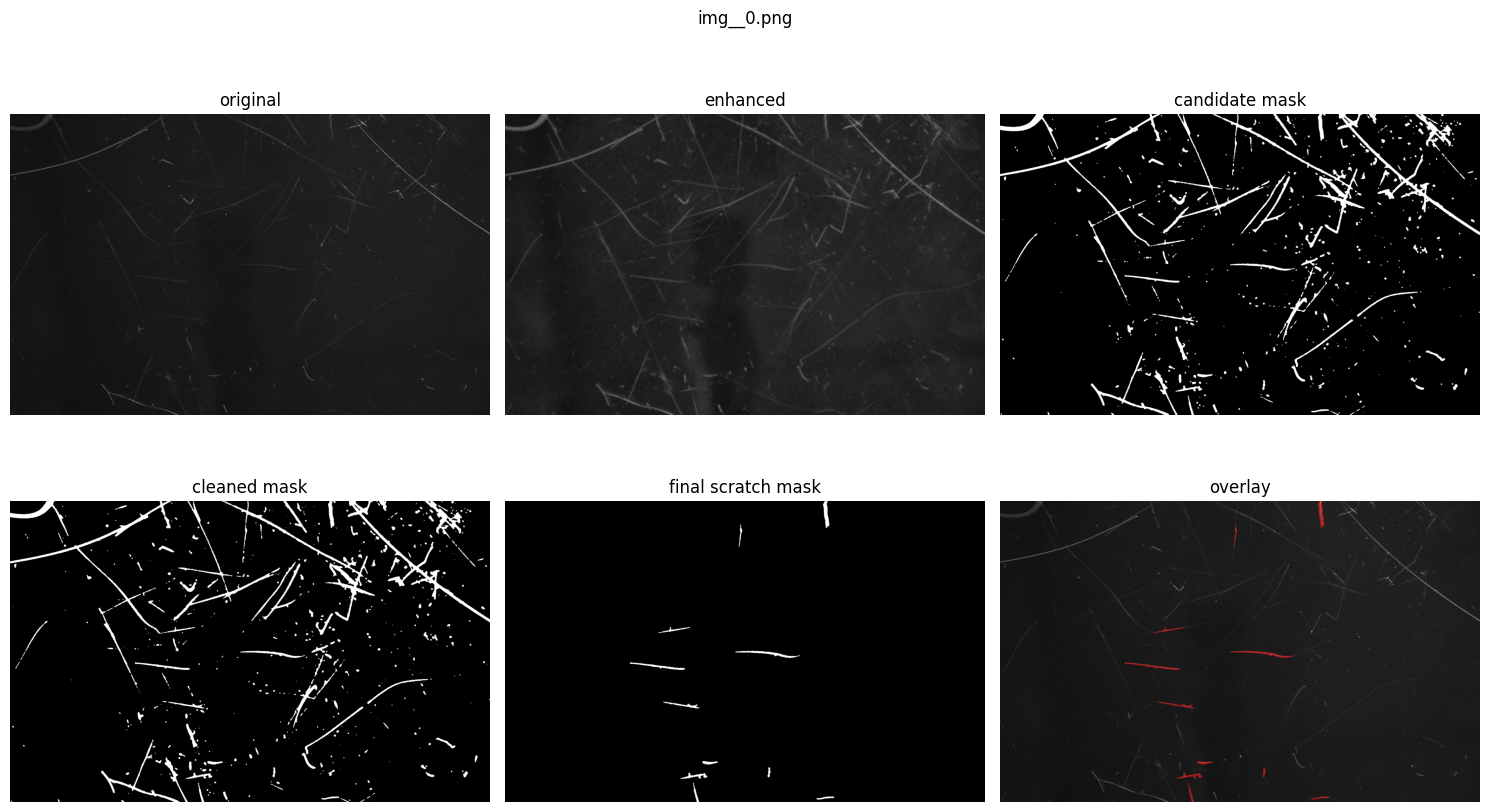

In [29]:
def overlay_mask(gray: np.ndarray, mask: np.ndarray, color=(0, 0, 255), alpha: float = 0.5) -> np.ndarray:
    """Alpha-blend the mask on top of the grayscale image as a colored overlay.

    I_ovl = (1 - α)·I + α·C_mask, with C_mask = color at mask>0, 0 elsewhere.
    Color is BGR (OpenCV convention); (0,0,255) = pure red.
    """
    bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
    paint = np.zeros_like(bgr); paint[mask > 0] = color
    return cv.addWeighted(bgr, 1.0, paint, alpha, 0)

def show_debug(img: np.ndarray, res: dict, title: str = ''):
    ov = overlay_mask(img, res['final'])
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    show(img,                'original',         axes[0, 0])
    show(res['stages']['clahe'], 'enhanced',     axes[0, 1])
    show(res['candidate'],   'candidate mask',   axes[0, 2])
    show(res['cleaned'],     'cleaned mask',     axes[1, 0])
    show(res['final'],       'final scratch mask', axes[1, 1])
    axes[1, 2].imshow(cv.cvtColor(ov, cv.COLOR_BGR2RGB)); axes[1, 2].set_title('overlay'); axes[1, 2].set_axis_off()
    fig.suptitle(title); plt.tight_layout(); plt.show()

res = build_mask(sample, P)
show_debug(sample, res, sample_path.name)

## 9. Batch processing

For every image in `RAW_DIR`:

1. load → preprocess → threshold → clean → filter
2. save the final mask to `MASKS_DIR/<same_name>`
3. save a side-by-side debug strip to `DEBUG_DIR/<same_name>`

In [30]:
def save_debug_overlay(img: np.ndarray, res: dict, src_path: Path, out_dir: Path) -> Path:
    """4-panel horizontal strip [original | candidate | final | overlay]."""
    ov = overlay_mask(img, res['final'])
    cand_bgr  = cv.cvtColor(res['candidate'], cv.COLOR_GRAY2BGR)
    final_bgr = cv.cvtColor(res['final'],     cv.COLOR_GRAY2BGR)
    img_bgr   = cv.cvtColor(img,              cv.COLOR_GRAY2BGR)
    strip = np.concatenate([img_bgr, cand_bgr, final_bgr, ov], axis=1)
    out_path = out_dir / src_path.name
    cv.imwrite(str(out_path), strip)
    return out_path

def process_batch(raw_dir: Path, mask_dir: Path, debug_dir: Path,
                  p: Params, save_debug: bool = True) -> pd.DataFrame:
    rows = []
    paths = list_images(raw_dir)
    for i, src in enumerate(paths, 1):
        img = load_gray(src)
        res = build_mask(img, p)
        m_path = save_mask(res['final'], src, mask_dir)
        d_path = save_debug_overlay(img, res, src, debug_dir) if save_debug else None
        rows.append(dict(
            name=src.name,
            shape=f'{img.shape[1]}x{img.shape[0]}',
            scratch_px=int((res['final'] > 0).sum()),
            components_total=len(res['components']),
            components_kept=int(res['components'].kept.sum()),
            mask=str(m_path),
            debug=str(d_path) if d_path else '',
        ))
        if i % 10 == 0 or i == len(paths):
            print(f'  {i}/{len(paths)}')
    return pd.DataFrame(rows)

# Run on the whole folder. Comment out if you are still tuning on one image.
# summary = process_batch(RAW_DIR, MASKS_DIR, DEBUG_DIR, P)
# summary

## 10. Dataset preparation for a future U-Net

Two non-obvious points:

1. **Resize masks with `INTER_NEAREST`.** Bilinear would produce intermediate values (e.g. 128) at scratch edges → no longer a valid binary label.
2. **Split by source image, not by tile.** Tiles from one photo are correlated; if some end up in *train* and others in *val*, the network memorises the photo and validation metrics overstate generalisation:

$$
\mathcal{S} = \mathcal{S}_{tr} \sqcup \mathcal{S}_{val} \sqcup \mathcal{S}_{te}
\;\Longrightarrow\;
\mathcal{T}_{tr} = \bigcup_{s\in\mathcal{S}_{tr}} \mathcal{T}_s, \text{ etc.}
$$

Tile rejection: drop a tile if scratch-pixel fraction $\rho = \tfrac{1}{HW}\sum_{x,y}\mathbf{1}[M(x,y)>0]$ is below `MIN_POS_FRAC`.

In [31]:
DATASET_DIR = ROOT / 'dataset'
for split in ('train', 'val', 'test'):
    (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / 'masks' ).mkdir(parents=True, exist_ok=True)

TILE_SIZE   = 512
TILE_STRIDE = 512
MIN_POS_FRAC = 1e-4

def resize_pair(img, mask, size):
    """Image: area-resampling (anti-aliased downscale). Mask: nearest-neighbour to keep labels binary."""
    img_r  = cv.resize(img,  size, interpolation=cv.INTER_AREA)
    mask_r = cv.resize(mask, size, interpolation=cv.INTER_NEAREST)
    return img_r, mask_r

def tile_pair(img, mask, tile: int = TILE_SIZE, stride: int = TILE_STRIDE):
    H, W = img.shape[:2]
    for y in range(0, H - tile + 1, stride):
        for x in range(0, W - tile + 1, stride):
            yield img[y:y+tile, x:x+tile], mask[y:y+tile, x:x+tile], (y, x)

def is_non_empty(mask_tile, min_frac: float = MIN_POS_FRAC) -> bool:
    return (mask_tile > 0).mean() >= min_frac

def check_pairs(raw_dir: Path, mask_dir: Path) -> pd.DataFrame:
    rows = []
    for src in list_images(raw_dir):
        m = mask_dir / src.name
        rows.append(dict(name=src.name, mask_exists=m.exists()))
    return pd.DataFrame(rows)

def split_by_image(names, val_frac: float = 0.15, test_frac: float = 0.15, seed: int = 0):
    """Disjoint train/val/test split over SOURCE images."""
    rng = np.random.default_rng(seed)
    names = np.array(sorted(names)); rng.shuffle(names)
    n_test = int(round(len(names) * test_frac))
    n_val  = int(round(len(names) * val_frac))
    test, val, train = names[:n_test], names[n_test:n_test+n_val], names[n_test+n_val:]
    return dict(train=list(train), val=list(val), test=list(test))

# Skeleton — fill in once masks look good:
# pairs = check_pairs(RAW_DIR, MASKS_DIR); print(pairs)
# splits = split_by_image([p.name for p in list_images(RAW_DIR)])
# for split, names in splits.items():
#     for n in names:
#         img  = load_gray(RAW_DIR / n)
#         mask = load_gray(MASKS_DIR / n)
#         for k, (it, mt, _) in enumerate(tile_pair(img, mask)):
#             if not is_non_empty(mt):
#                 continue
#             stem = Path(n).stem
#             cv.imwrite(str(DATASET_DIR / split / 'images' / f'{stem}_{k:04d}.png'), it)
#             cv.imwrite(str(DATASET_DIR / split / 'masks'  / f'{stem}_{k:04d}.png'), mt)

## 11. Future PyTorch ingredients

Placeholders only — do not train here. Two loss components designed for the **heavy class imbalance** of scratch segmentation (foreground is < 1 % of pixels):

**Binary Cross-Entropy** (per-pixel, with logits $\hat z$ and target $y\in\{0,1\}$):

$$
\mathcal{L}_{\mathrm{BCE}}(\hat z, y) = -\frac{1}{N}\sum_{i=1}^{N}\Bigl[y_i\,\log\sigma(\hat z_i) + (1-y_i)\,\log\bigl(1-\sigma(\hat z_i)\bigr)\Bigr]
$$

**Soft Dice loss** (overlap-based, invariant to class frequency):

$$
\mathcal{L}_{\mathrm{Dice}}(\hat p, y) = 1 - \frac{2\sum_i \hat p_i\,y_i + \varepsilon}{\sum_i \hat p_i + \sum_i y_i + \varepsilon},\quad \hat p_i = \sigma(\hat z_i)
$$

Combined: $\mathcal{L} = \mathcal{L}_{\mathrm{BCE}} + \mathcal{L}_{\mathrm{Dice}}$.

In [32]:
PYTORCH_PLAN = r'''
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn.functional as F

class ScratchDataset(Dataset):
    """Yields (image_tensor[1,H,W], mask_tensor[1,H,W]) pairs.

    - image:  float32 in [0, 1]   (normalisation = divide by 255)
    - mask:   float32 in {0, 1}   (binary label for BCE / Dice)
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs  = sorted(Path(img_dir).iterdir())
        self.masks = [Path(mask_dir) / p.name for p in self.imgs]
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img  = cv.imread(str(self.imgs[i]),  cv.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        mask = cv.imread(str(self.masks[i]), cv.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            img, mask = self.transform(img, mask)
        return torch.from_numpy(img)[None], torch.from_numpy(mask)[None]

def bce_dice_loss(pred_logits, target, eps=1e-6):
    """L = BCE(σ(ẑ), y) + Dice(σ(ẑ), y). Uses _with_logits for numerical stability."""
    bce = F.binary_cross_entropy_with_logits(pred_logits, target)
    p   = torch.sigmoid(pred_logits)
    inter = (p * target).sum(dim=(2, 3))
    denom = p.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice  = 1 - (2 * inter + eps) / (denom + eps)
    return bce + dice.mean()
'''
print(PYTORCH_PLAN)


from torch.utils.data import Dataset, DataLoader
import torch, torch.nn.functional as F

class ScratchDataset(Dataset):
    """Yields (image_tensor[1,H,W], mask_tensor[1,H,W]) pairs.

    - image:  float32 in [0, 1]   (normalisation = divide by 255)
    - mask:   float32 in {0, 1}   (binary label for BCE / Dice)
    """
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs  = sorted(Path(img_dir).iterdir())
        self.masks = [Path(mask_dir) / p.name for p in self.imgs]
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img  = cv.imread(str(self.imgs[i]),  cv.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        mask = cv.imread(str(self.masks[i]), cv.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            img, mask = self.transform(img, mask)
        return torch.from_numpy(img)[None], torch.from_numpy(mask)[None]

def bce_dice_loss(pred_logits, t